# Qwen3-VL（Qwen3 Vision Language）模型

> **论文**：*Qwen3 Technical Report*（Qwen Team, Alibaba, 2025）  
> **核心思想**：在 Qwen3 大语言模型基础上引入 **ViT 视觉编码器**，通过 **Patch Merger** 将相邻视觉 patch 在空间维度合并后投影到 LLM 隐藏空间，配合 **DeepStack** 中间层早期融合机制向 LLM 注入多尺度视觉特征，实现高质量图文理解与多轮对话推理。  
> **核心组件**：Qwen3VL ViT 视觉编码器（24 层，hidden=1024）→ Patch Merger（2×2 空间合并 + 跨模态投影至 2048）→ DeepStack 中间层早期融合 → Qwen3 语言模型主干（28 层，hidden=2048，GQA + SwiGLU）→ LM Head

## 一、环境检查与依赖安装

In [1]:
import subprocess  # 用于调用子进程执行系统命令（如 pip install）
import sys         # 提供 Python 解释器相关变量（如 sys.executable 当前解释器路径）

# 直接尝试导入后续代码真正会用到的符号，而非只检查子模块是否存在：
# - 若 transformers 版本过低：Qwen3VLForConditionalGeneration 不存在，抛 ImportError
# - 若 huggingface_hub  版本过低：import transformers 内部缺少 is_offline_mode，抛 RuntimeError
# 两种情况都会被 except 捕获，统一触发升级
try:
    import transformers
    from transformers import AutoProcessor, Qwen3VLForConditionalGeneration
    print(f"环境满足要求，transformers 版本: {transformers.__version__}")
except (ImportError, RuntimeError) as e:
    print(f"依赖版本不满足要求，原因: {e}")
    print("正在升级 transformers 与 huggingface_hub ...")
    # 同时升级两个包：transformers>=4.57.0 依赖 huggingface_hub 中的新符号（如 is_offline_mode），
    # -U 强制升级到最新兼容版本，pip 自动解析依赖约束
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-U",
        "transformers>=4.57.0",
        "huggingface_hub",
        "-q",
    ])
    # 两个包均含大量子模块，importlib.reload 无法递归刷新 sys.modules 缓存，
    # 必须重启内核才能使新版本完全生效
    print("升级完成！请重启内核（Kernel → Restart Kernel）后重新运行此 Notebook。")

环境满足要求，transformers 版本: 5.14.1


## 二、模型加载与推理

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Processor 结构:
Qwen3VLProcessor:
- image_processor: Qwen2VLImageProcessor {
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "Qwen2VLImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "merge_size": 2,
  "patch_size": 16,
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "longest_edge": 16777216,
    "shortest_edge": 65536
  },
  "temporal_patch_size": 2
}

- tokenizer: Qwen2Tokenizer(name_or_path='Qwen/Qwen3-VL-2B-Instruct', vocab_size=151643, model_max_length=262144, padding_side='right', truncation_side='right', special_tokens={'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}, added_tokens_decoder={
	151643: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	151644: AddedToken("<|im_start|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special

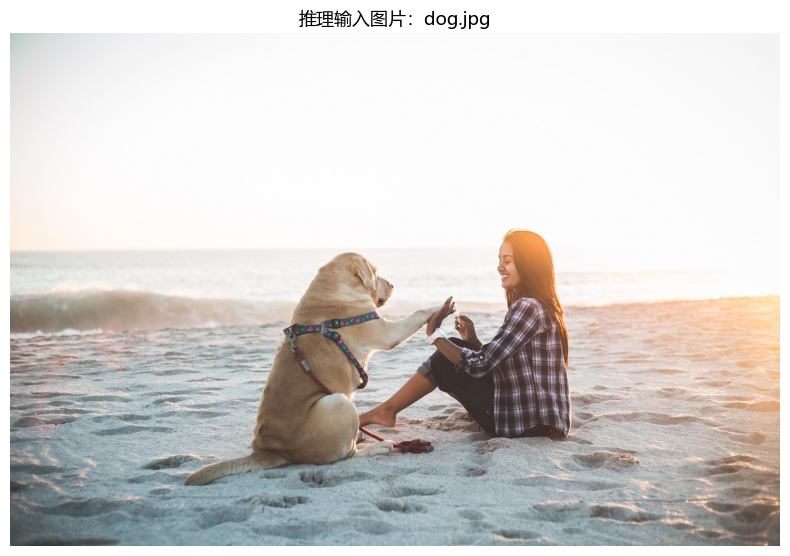

In [2]:
import torch  # PyTorch 深度学习框架，提供张量计算与 GPU 加速
from pathlib import Path  # 面向对象的文件路径操作库
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration  # 自动处理器与 Qwen3-VL 条件生成模型类

# Hugging Face Hub 上的模型仓库 ID
MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
# 待推理的本地图片路径（与 Notebook 同目录）
IMAGE_PATH = Path("dog.jpg")


def load_qwen3_vl_model(model_id: str = MODEL_ID):
    """
    从 Hugging Face Hub 或本地路径加载 Qwen3-VL 多模态模型与配套处理器。

    Args:
        model_id (str): 模型仓库名称或本地目录路径，默认 "Qwen/Qwen3-VL-2B-Instruct"。

    Returns:
        model (Qwen3VLForConditionalGeneration): 已加载的 Qwen3-VL 多模态条件生成模型，
            参数根据可用资源自动分配到 GPU / CPU / 磁盘。
        processor (AutoProcessor): 与模型配套的多模态处理器，
            内部封装了图像预处理器（Qwen2VLImageProcessor）和分词器（Qwen2Tokenizer）。
    """
    # dtype="auto"：根据设备自动选择权重数据类型（如 bfloat16 / float16 / float32），节省显存
    # device_map="auto"：将各层自动分配到 GPU / CPU / 磁盘，支持大模型在单卡或多卡上加载
    model = Qwen3VLForConditionalGeneration.from_pretrained(
        model_id,           # 模型 ID 或本地路径
        dtype="auto",       # 自动推断权重 dtype
        device_map="auto",  # 自动设备映射
        cache_dir="model_cache/Qwen3VL",
    )
    # 加载处理器：内含图像预处理（缩放、归一化、patch 切分）与文本分词两个子组件
    processor = AutoProcessor.from_pretrained(model_id,cache_dir="model_cache/Qwen3VL")
    return model, processor  # 返回 (模型实例, 处理器实例) 元组


def print_model_structure(model, processor):
    """
    打印模型与处理器的层级结构及关键统计指标。

    Args:
        model (Qwen3VLForConditionalGeneration): 已加载的 Qwen3-VL 模型实例。
        processor (AutoProcessor): 已加载的多模态处理器实例。

    Returns:
        None：本函数仅打印信息，无返回值。
    """
    print("=" * 100)  # 视觉分隔线
    print("Processor 结构:")  # 处理器结构标题
    # 打印处理器对象的字符串表示，显示图像预处理器（Qwen2VLImageProcessor）与分词器配置
    print(processor)
    print("=" * 100)
    # 统计总参数量：p.numel() 返回每个参数张量的元素数，除以 1e9 转换为十亿（B）单位
    print(f"模型参数量: {sum(p.numel() for p in model.parameters()) / 1e9:.2f} B")
    # next(model.parameters()).device 获取第一个参数所在设备，代表模型主体的部署位置
    print(f"模型设备: {next(model.parameters()).device}")
    # 获取模型权重的数据类型（torch.float16 / torch.bfloat16 / torch.float32 等）
    print(f"模型 dtype: {next(model.parameters()).dtype}")


def build_messages(image_path: Path, question: str):
    """
    按照 Qwen3-VL 对话模板格式，构建包含图像与文本的多模态消息列表。

    Args:
        image_path (Path): 本地图片文件的 Path 对象，内部转为绝对路径字符串传入模型。
        question (str): 用户针对图片提出的问题文本。

    Returns:
        messages (List[Dict]): 符合 apply_chat_template 要求的消息列表，结构为：
            [
                {
                    "role": "user",   # 消息角色，固定为用户
                    "content": [      # 内容列表，图文混合排列
                        {"type": "image", "image": "<绝对路径字符串>"},
                        {"type": "text",  "text":  "<问题文本>"},
                    ]
                }
            ]
    """
    return [
        {
            "role": "user",  # 消息角色：用户
            "content": [
                # 图像内容项：type="image" 告知处理器此项为图片，image 字段为绝对路径
                {"type": "image", "image": str(image_path.resolve())},
                # 文本内容项：type="text" 告知处理器此项为纯文本问题
                {"type": "text", "text": question},
            ],
        }
    ]


def run_inference(model, processor, messages, max_new_tokens: int = 1024):
    """
    对给定的多模态消息执行 Qwen3-VL 推理，返回模型生成的文本回答。

    Args:
        model (Qwen3VLForConditionalGeneration): 已加载的 Qwen3-VL 模型。
        processor (AutoProcessor): 已加载的多模态处理器。
        messages (List[Dict]): 由 build_messages 构建的对话消息列表。
        max_new_tokens (int): 最大新生成 token 数量，默认 128。

    Returns:
        output_text (str): 模型针对输入图文生成的文本回答字符串。
    """
    # apply_chat_template 将结构化 messages 转换为模型可接受的输入张量
    # tokenize=True          → 对文本分词并编码为 token ID（整数序列）
    # add_generation_prompt  → 在序列末尾追加生成起始标记，引导模型开始续写
    # return_dict=True       → 以 BatchEncoding 字典形式返回，便于直接解包传入模型
    # return_tensors="pt"    → 返回 PyTorch 张量格式
    inputs = processor.apply_chat_template(
        messages,                      # 多模态对话消息列表
        tokenize=True,                 # 对文本部分分词并编码
        add_generation_prompt=True,    # 追加生成起始提示符
        return_dict=True,              # 返回 BatchEncoding 字典
        return_tensors="pt",           # 返回 PyTorch 张量
    )
    # 将所有输入张量迁移到模型所在设备（CPU / GPU）
    # inputs（BatchEncoding）包含以下关键字段：
    #   input_ids:      shape [batch_size=1, seq_len]
    #                   token ID 序列，seq_len 含图像占位符 token
    #   attention_mask: shape [batch_size=1, seq_len]
    #                   有效位置为 1，填充位置为 0
    #   pixel_values:   shape [num_patches, channels=3, patch_h, patch_w]
    #                   图像被切分为若干 patch 后的像素值（已归一化）
    #   image_grid_thw: shape [num_images=1, 3]
    #                   每张图像的时间/高/宽 patch 网格大小（t, h, w）
    inputs = inputs.to(model.device)

    with torch.inference_mode():  # 推理模式：禁用梯度计算，节省显存并加速
        # model.generate 自回归逐 token 生成新内容
        # **inputs 解包 BatchEncoding 中所有字段（input_ids、attention_mask、pixel_values 等）
        # generated_ids shape: [batch_size=1, seq_len + num_new_tokens]
        #   前 seq_len 个 token 为输入（含图像占位符），后 num_new_tokens 个为新生成内容
        generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)

    # 去除输入部分，仅保留新生成的 token ID
    # in_ids:  单样本输入 token 序列，shape [seq_len]
    # out_ids: 单样本完整输出序列，shape [seq_len + num_new_tokens]
    # out_ids[len(in_ids):]：切片截取尾部新生成部分，shape [num_new_tokens]
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    # 将新生成的 token ID 序列解码为可读字符串
    # generated_ids_trimmed: List[Tensor]，列表长度 = batch_size=1，每个 Tensor shape [num_new_tokens]
    # skip_special_tokens=True        → 过滤 <|im_start|>、<|im_end|> 等特殊 token
    # clean_up_tokenization_spaces=False → 保留原始空格分布，避免中文输出被额外插入空格
    # 返回值 output_text: List[str]，长度 = batch_size=1
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,            # 过滤特殊 token
        clean_up_tokenization_spaces=False,  # 保持原始空格
    )
    return output_text[0]  # 返回第 0 个元素，即本批次唯一样本的生成文本（str 类型）


# 步骤 1：加载 Qwen3-VL 模型与处理器
# model:     Qwen3VLForConditionalGeneration 实例
# processor: AutoProcessor 实例（内含图像预处理器与分词器）
model, processor = load_qwen3_vl_model()

# 步骤 2：打印模型与处理器结构及统计信息
print_model_structure(model, processor)

# 步骤 3：构建图文对话消息并执行推理
question = "请详细描述这张图片的内容。"      # 用户提问文本
messages = build_messages(IMAGE_PATH, question)  # 构建多模态消息列表
answer = run_inference(model, processor, messages)  # 执行推理，返回生成文本字符串

print("=" * 100)
print(f"问题: {question}")  # 打印输入问题
print(f"回答: {answer}")    # 打印模型生成的回答

import matplotlib.pyplot as plt   # 可视化库，用于显示图像和绘图
import matplotlib.image as mpimg  # 图像读取模块，支持直接读取 PNG/JPG 等格式

# ── 配置中文字体，避免标题中文字符显示为方框或触发 UserWarning ─────────────────
# matplotlib 默认字体 DejaVu Sans 不含 CJK 字形；
# 此处按优先级依次尝试 Windows 内置中文字体，找到可用字体即停止回退
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "SimSun", "DejaVu Sans"]
# 修复负号在中文字体下显示为方块的问题
plt.rcParams["axes.unicode_minus"] = False

# ── 可视化推理所用的输入图片 ──────────────────────────────────────────────────
# figsize=(8, 6)：画布宽 8 英寸、高 6 英寸
fig, ax = plt.subplots(figsize=(8, 6))

# mpimg.imread 读取本地图片为 NumPy 数组
# 返回值 img：shape [height, width, channels=3]，RGB 通道，像素值范围 0~255（uint8）
img = mpimg.imread(str(IMAGE_PATH))

ax.imshow(img)   # 在坐标轴上渲染 RGB 图像
ax.axis("off")   # 隐藏坐标轴刻度与边框，使显示更简洁

# set_title：为子图设置标题，fontsize=13 指定字号
ax.set_title(f"推理输入图片：{IMAGE_PATH.name}", fontsize=13)

plt.tight_layout()  # 自动收紧布局，防止标题与图像内容重叠
plt.show()          # 渲染并在 Notebook 内联显示图形

## 三、模型结构展示

```python
# Qwen3-VL-2B-Instruct 完整模型结构（由 print(model) 输出，总参数量约 2B）
Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(

    # ── 一、视觉编码器（Vision Transformer / ViT）──────────────────────────────
    (visual): Qwen3VLVisionModel(

      # Patch 嵌入层：用 3D 卷积将图像/视频帧分割为 patch 并投影到视觉隐藏空间
      # Conv3d 参数说明：
      #   in_channels=3          → 输入为 RGB 三通道图像
      #   out_channels=1024      → 每个 patch 投影为 1024 维向量（视觉 hidden_size）
      #   kernel_size=(2,16,16)  → 时间维合并相邻 2 帧，空间维每块 16×16 像素
      #   stride=(2,16,16)       → 步长与 kernel 相同，patch 之间无重叠
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )

      # 绝对位置编码（可学习 Embedding）：
      #   num_embeddings=2304 → 位置编码表的词表大小（预训练阶段见过的 patch 位置数）
      #   实际 patch 数可超过 2304；超出时对位置编码做双线性插值以适应更大分辨率
      #   embedding_dim=1024  → 与 patch 向量维度相同，直接相加作为位置信息
      (pos_embed): Embedding(2304, 1024)

      # 视觉旋转位置编码（RoPE）：为 2D/3D 视觉 token 提供相对空间位置感知
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()

      # 视觉 Transformer 主干：共 24 个堆叠 Block，逐层提取深层视觉语义特征
      (blocks): ModuleList(
        (0-23): 24 x Qwen3VLVisionBlock(

          # 注意力前 Pre-Norm：对 1024 维 token 做 LayerNorm，稳定注意力输入分布
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          # FFN 前 Pre-Norm：对注意力输出 1024 维向量做 LayerNorm
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)

          # 视觉多头自注意力（Multi-Head Self-Attention）
          # qkv：融合线性层，1024 → 3072（= 1024×3，同时投影 Q、K、V 拼接输出）
          # proj：输出线性层，将多头拼接结果从 1024 映射回 1024
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )

          # 视觉前馈网络（Vision FFN）
          # linear_fc1：升维 1024 → 4096（扩展比≈4，增强非线性表达能力）
          # linear_fc2：降维 4096 → 1024（还原 hidden_size）
          # act_fn：GELUTanh（GELU 的 tanh 近似实现，兼顾精度与速度）
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (linear_fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (act_fn): GELUTanh()
          )
        )
      )

      # 视觉 Patch 合并器（空间合并 + 跨模态投影）
      # 将相邻 2×2=4 个 patch（各 1024 维）拼接为 4096 维，再投影到 LLM hidden_size
      # 拼接维度计算：1024 × spatial_merge_size² = 1024 × 2² = 4096
      # norm：先对单 patch（1024 维）做 LayerNorm，再 reshape 为 4096
      # linear_fc1：特征变换 4096 → 4096
      # linear_fc2：跨模态对齐投影 4096 → 2048（对齐 LLM 的 hidden_size=2048）
      (merger): Qwen3VLVisionPatchMerger(
        (norm): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (linear_fc1): Linear(in_features=4096, out_features=4096, bias=True)
        (act_fn): GELU(approximate='none')
        (linear_fc2): Linear(in_features=4096, out_features=2048, bias=True)
      )

      # DeepStack 中间层合并器列表（共 3 个，对应 ViT 第 5、11、17 层的中间特征）
      # DeepStack 将 ViT 中间层特征提前注入 LLM 对应层（早期多模态融合），增强细粒度视觉理解
      # 与 merger 区别：norm 作用于合并后的 4096 维（use_postshuffle_norm=True）
      (deepstack_merger_list): ModuleList(
        (0-2): 3 x Qwen3VLVisionPatchMerger(
          (norm): LayerNorm((4096,), eps=1e-06, elementwise_affine=True)
          (linear_fc1): Linear(in_features=4096, out_features=4096, bias=True)
          (act_fn): GELU(approximate='none')
          (linear_fc2): Linear(in_features=4096, out_features=2048, bias=True)
        )
      )
    )

    # ── 二、语言模型主干（LLM Backbone，因果自回归 Transformer）───────────────
    (language_model): Qwen3VLTextModel(

      # 词 token 嵌入层：
      #   num_embeddings=151936 → 词表大小（含视觉特殊 token 和控制 token）
      #   embedding_dim=2048    → LLM 隐藏维度（hidden_size）
      (embed_tokens): Embedding(151936, 2048)

      # 解码器层堆叠：共 28 层因果 Transformer Block（每层含注意力 + FFN）
      (layers): ModuleList(
        (0-27): 28 x Qwen3VLTextDecoderLayer(

          # 分组查询注意力（GQA，Grouped-Query Attention）
          # q_proj：查询投影，2048 → 2048（16 个查询头 × 每头 128 维）
          # k_proj：键投影，2048 → 1024（8 个键头 × 每头 128 维，GQA 减少 KV 头数节省显存）
          # v_proj：值投影，2048 → 1024（键值头数相同，每 2 个查询头共享 1 个键值头）
          # o_proj：输出投影，多头注意力结果拼接后从 2048 映射回 2048
          # q_norm/k_norm：对每头的 Q/K 向量（128 维）做 RMSNorm，防止注意力分布退化
          (self_attn): Qwen3VLTextAttention(
            (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
            (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
            (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
            (q_norm): Qwen3VLTextRMSNorm((128,), eps=1e-06)
            (k_norm): Qwen3VLTextRMSNorm((128,), eps=1e-06)
          )

          # SwiGLU 前馈网络（FFN）
          # gate_proj / up_proj：并行升维 2048 → 6144（门控线性单元，扩展比=3）
          # down_proj：降维 6144 → 2048（还原 hidden_size）
          # act_fn：SiLU（Sigmoid Linear Unit / Swish），配合门控实现 SwiGLU
          (mlp): Qwen3VLTextMLP(
            (gate_proj): Linear(in_features=2048, out_features=6144, bias=False)
            (up_proj): Linear(in_features=2048, out_features=6144, bias=False)
            (down_proj): Linear(in_features=6144, out_features=2048, bias=False)
            (act_fn): SiLUActivation()
          )

          # Pre-Norm（注意力前）：RMSNorm 对 2048 维输入归一化，稳定训练
          (input_layernorm): Qwen3VLTextRMSNorm((2048,), eps=1e-06)
          # Pre-Norm（FFN 前）：RMSNorm 对注意力输出 2048 维向量归一化
          (post_attention_layernorm): Qwen3VLTextRMSNorm((2048,), eps=1e-06)
        )
      )

      # 最终归一化：对最后一层 Transformer 输出的 2048 维 hidden state 做 RMSNorm
      (norm): Qwen3VLTextRMSNorm((2048,), eps=1e-06)
      # 文本旋转位置编码（RoPE）：为语言 token 提供相对位置信息，支持长上下文外推
      (rotary_emb): Qwen3VLTextRotaryEmbedding()
    )
  )

  # ── 三、语言模型输出头（LM Head）──────────────────────────────────────────────
  # 将 LLM 最终输出的 hidden_size=2048 维向量线性映射到词表大小=151936
  # 输出 logits shape：[batch_size, seq_len, vocab_size=151936]
  # 每个位置的 logits 经 softmax 后得到下一个 token 的概率分布
  # bias=False：不使用偏置项；通常与 embed_tokens 共享权重（weight tying）以减少参数量
  (lm_head): Linear(in_features=2048, out_features=151936, bias=False)
)
```

## 四、3D 卷积原理详解

### 4.1 2D 卷积回顾：图像 Patch 嵌入（ViT 做法）

In [ ]:
import torch           # PyTorch 深度学习框架，提供张量计算
import torch.nn as nn  # 神经网络模块，提供各类层定义

# ── 构造输入张量：模拟一批 RGB 图像 ──────────────────────────────────────────
# 2D 卷积处理静态图像，输入为四维张量：[B, C, H, W]
#   B=2   → batch_size，本次批量处理 2 张图像
#   C=3   → 输入通道数（RGB 三通道）
#   H=224 → 图像高度（像素）
#   W=224 → 图像宽度（像素）
x_2d = torch.randn(2, 3, 224, 224)
print(f"输入 shape : {x_2d.shape}")
# torch.Size([2, 3, 224, 224])

# ── 定义 2D 卷积层（等价于 ViT 的 Patch Embedding）───────────────────────────
# in_channels=3    → 输入 RGB 三通道
# out_channels=768 → 每个 patch 投影为 768 维向量（ViT-Base hidden_size）
# kernel_size=16   → 卷积核覆盖 16×16 像素区域，即一个 patch 的大小
# stride=16        → 步长等于 kernel_size，patch 之间无重叠（非滑动窗口）
conv2d = nn.Conv2d(in_channels=3, out_channels=768, kernel_size=16, stride=16)

out_2d = conv2d(x_2d)  # 对输入执行 2D 卷积，得到各 patch 的特征图
print(f"卷积输出 shape : {out_2d.shape}")
# torch.Size([2, 768, 14, 14])
# 含义：
#   2   → batch_size（2 张图像）
#   768 → out_channels（每个 patch 对应的特征向量维度）
#   14  → H_out = 224 / 16 = 14（高度方向 patch 数）
#   14  → W_out = 224 / 16 = 14（宽度方向 patch 数）
# 14 × 14 = 196 个 patch（与 ViT-B/16 标准配置完全一致）

# ── 将空间特征图展平为 Transformer 所需的 token 序列 ──────────────────────────
# flatten(2)     : 将第 2 维起的所有维度合并
#                  [B=2, C=768, H=14, W=14] → [B=2, C=768, 196]
# transpose(1,2) : 交换通道维与序列维
#                  [B=2, C=768, 196] → [B=2, seq_len=196, hidden=768]
tokens_2d = out_2d.flatten(2).transpose(1, 2)
print(f"Token  shape : {tokens_2d.shape}")
# torch.Size([2, 196, 768])
# 含义：
#   2   → batch_size
#   196 → 序列长度（196 个图像 patch token）
#   768 → 每个 token 的特征维度（hidden_size）


### 4.2 3D 卷积：时空 Patch 嵌入

In [ ]:
import torch
import torch.nn as nn

# ── 2D 卷积 vs 3D 卷积的核心区别 ──────────────────────────────────────────────
# 2D 卷积：输入 [B, C, H, W]        → 卷积核在 H×W 二维空间上滑动
# 3D 卷积：输入 [B, C, T, H, W]     → 卷积核在 T×H×W 三维时空上滑动
#           T（Temporal）为时间/帧数维度
#           可用于视频（多帧）或单张图像（复制帧以统一处理接口）

# ── 构造输入张量：模拟视频帧序列 ──────────────────────────────────────────────
# shape: [batch_size, channels, temporal, height, width]
#   B=1  → batch_size
#   C=3  → RGB 三通道
#   T=4  → 视频帧数（时间维度）
#   H=32 → 帧高度（像素）
#   W=32 → 帧宽度（像素）
x_video = torch.randn(1, 3, 4, 32, 32)
print(f"视频输入 shape : {x_video.shape}")

# ── 定义 3D 卷积层（完全复现 Qwen3-VL 的 patch_embed.proj 参数）───────────────
# in_channels=3           → 输入 RGB 三通道
# out_channels=1024       → 每个时空 patch 投影为 1024 维向量（视觉 hidden_size）
# kernel_size=(2, 16, 16) → 时间维合并 2 帧，空间维覆盖 16×16 像素
#                           即一个"时空 patch"跨 2 帧、16×16 像素
# stride=(2, 16, 16)      → 步长等于 kernel，时空 patch 之间无重叠
conv3d = nn.Conv3d(
    in_channels=3,
    out_channels=1024,
    kernel_size=(2, 16, 16),  # (时间, 高, 宽)
    stride=(2, 16, 16),       # (时间, 高, 宽)
)

out_video = conv3d(x_video)  # 对视频张量执行 3D 卷积
print(f"视频卷积输出 shape : {out_video.shape}")
# torch.Size([1, 1024, 2, 2, 2])
# 含义：
#   1    → batch_size
#   1024 → out_channels（每个时空 patch 的特征向量维度）
#   2    → T_out = 4 / 2 = 2（时间方向 patch 数，每 2 帧合并为 1 个时间步）
#   2    → H_out = 32 / 16 = 2（高度方向 patch 数）
#   2    → W_out = 32 / 16 = 2（宽度方向 patch 数）
# 共 2×2×2 = 8 个时空 patch token

# ── 展平为 token 序列 ──────────────────────────────────────────────────────────
# flatten(2)     : [B=1, C=1024, T=2, H=2, W=2] → [B=1, C=1024, T*H*W=8]
# transpose(1,2) : [B=1, C=1024, 8] → [B=1, seq_len=8, hidden=1024]
tokens_video = out_video.flatten(2).transpose(1, 2)
print(f"视频 token shape : {tokens_video.shape}")
# torch.Size([1, 8, 1024])
# 含义：
#   1    → batch_size
#   8    → 时空 patch token 数（2×2×2）
#   1024 → 每个 token 的特征维度

# ─────────────────────────────────────────────────────────────────────────────
# ── Qwen3-VL 处理单张图像时的 Conv3d 流程 ─────────────────────────────────────
# Qwen3-VL 统一使用 3D 卷积处理图像与视频：
# 单张图像（T=1）→ 沿时间维复制为 T=2（temporal_patch_size=2），
# 再送入 Conv3d(kernel_size=(2,16,16))，时间维恰好被完整合并为 1 个时间步
print()
print("─" * 60)

# 模拟 224×224 单张图像，在时间维复制为 2 帧
# shape: [B=1, C=3, T=2, H=224, W=224]
x_image = torch.randn(1, 3, 2, 224, 224)
print(f"单张图像（复制 2 帧）输入 shape : {x_image.shape}")

out_image = conv3d_qwen = nn.Conv3d(3, 1024, kernel_size=(2, 16, 16), stride=(2, 16, 16))
out_image = conv3d_qwen(x_image)  # 执行 Qwen3-VL 的 patch_embed.proj
print(f"Conv3d 输出 shape : {out_image.shape}")
# torch.Size([1, 1024, 1, 14, 14])
# 含义：
#   1    → batch_size
#   1024 → 视觉 hidden_size
#   1    → T_out = 2 / 2 = 1（2 帧合并为 1 个时间步）
#   14   → H_out = 224 / 16 = 14（高度方向 patch 数）
#   14   → W_out = 224 / 16 = 14（宽度方向 patch 数）

n_tokens = out_image.shape[2] * out_image.shape[3] * out_image.shape[4]
print(f"图像 patch token 数 : {out_image.shape[2]}(T) × {out_image.shape[3]}(H) × {out_image.shape[4]}(W) = {n_tokens}")
# 1 × 14 × 14 = 196 个视觉 token（与 ViT-B/16 完全一致）

# 展平后送入 ViT Transformer Block
tokens_image = out_image.flatten(2).transpose(1, 2)
print(f"展平后 token shape : {tokens_image.shape}")
# torch.Size([1, 196, 1024])
# 含义：
#   1    → batch_size
#   196  → 视觉序列长度（196 个图像 patch token）
#   1024 → 视觉 hidden_size，对应 Qwen3VL ViT 的 hidden_size
